# Avalanche Detection and Criticality

In [1]:
import numpy as np
import miv
from miv.signal.criticality import detect_avalanche

from miv.datasets.criticality import load_data

In [2]:
import matplotlib.pyplot as plt

In [3]:
import scipy.sparse as spa

In [4]:
type(spa.csc_matrix((3,4), dtype=np.int8))

scipy.sparse._csc.csc_matrix

In [5]:
from scipy.io import loadmat
filename = load_data()
data = loadmat(filename)

In [6]:
data.keys()

dict_keys(['__header__', '__version__', '__globals__', 'asdf_raw_all', 'IDs', 'asdf_raw', 'location'])

In [7]:
data['asdf_raw_all'].shape # Raw

(262, 1)

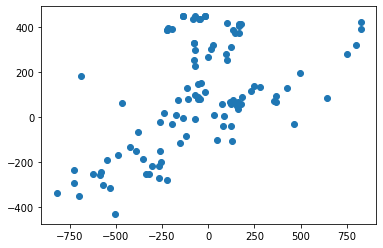

In [8]:
plt.scatter(data['location'][:,0], data['location'][:,1])

In [25]:
from neo.core import SpikeTrain
from elephant.conversion import BinnedSpikeTrain
import quantities as pq
import viziphant

In [35]:
r = 20000
end = 100
spike_trains = []
for d in data['asdf_raw']:
    d = d[0][0]
    spike_trains.append(SpikeTrain(d * pq.s / r, t_stop=end * pq.s))
bst = BinnedSpikeTrain(spike_trains, bin_size=0.1*pq.s, sparse_format='csc').to_sparse_array()

<AxesSubplot:xlabel='Time (s)'>

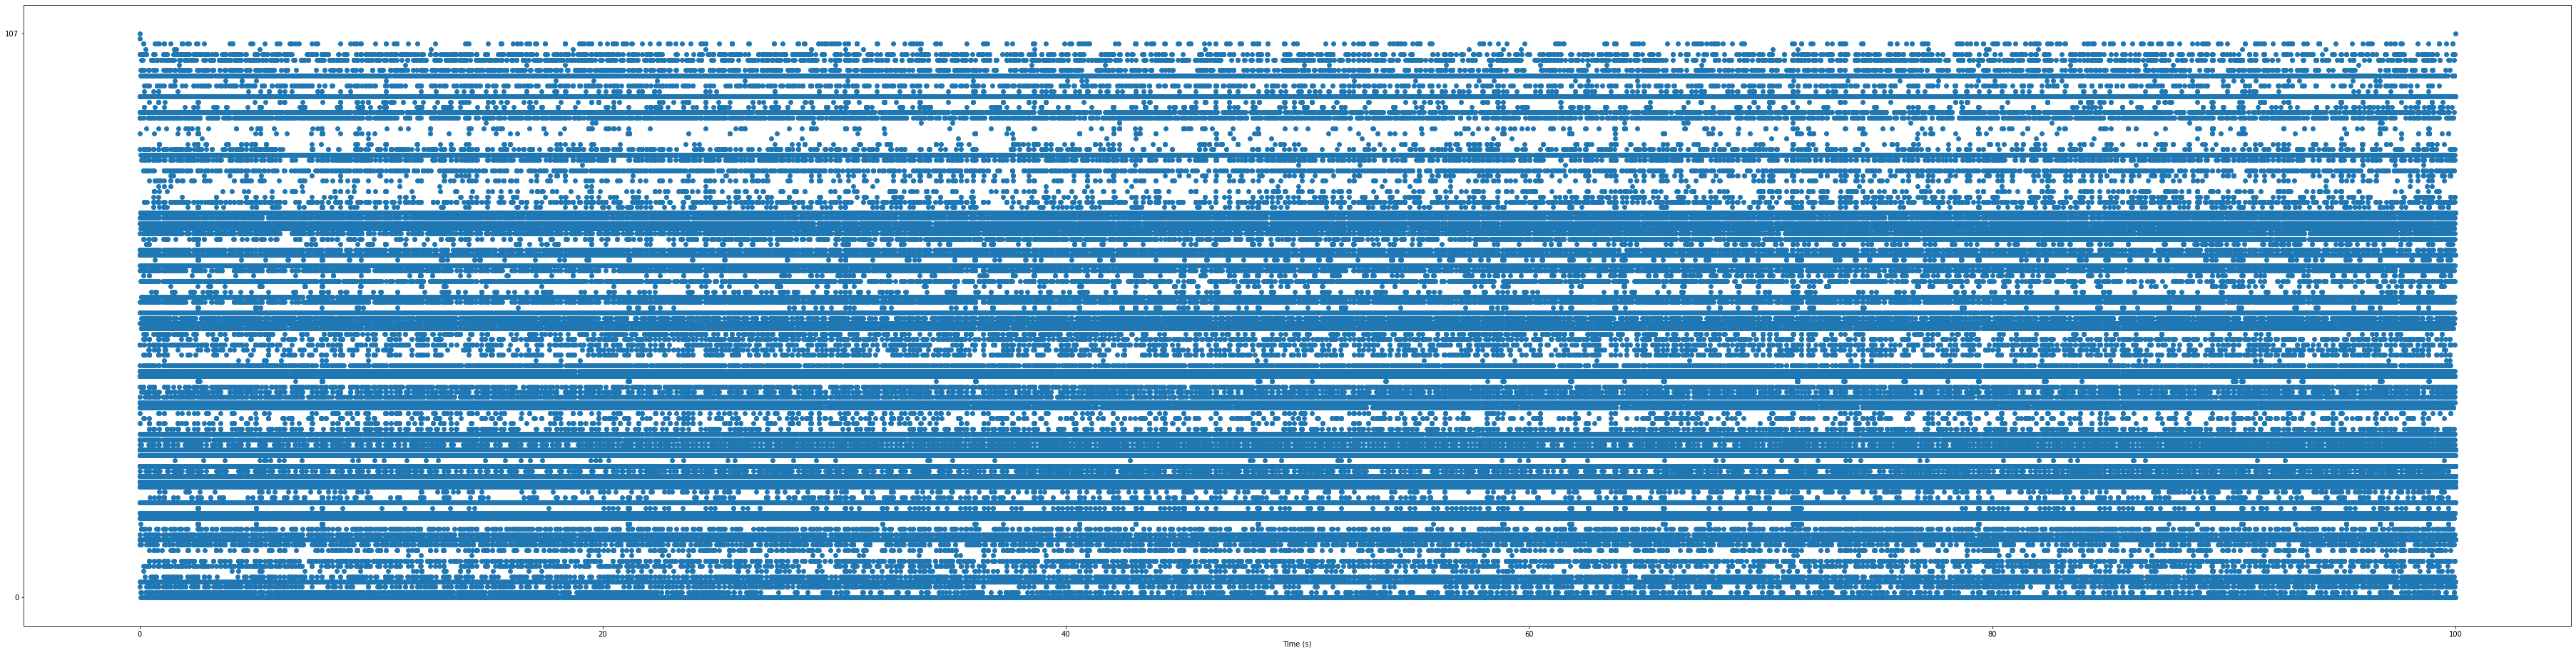

In [38]:
fig = plt.figure(figsize=(64,16))
viziphant.rasterplot.rasterplot(spike_trains, axes=plt.gca())

In [39]:
bst.shape

(108, 1000)

In [ ]:
data['IDs'].shape # Filtered channel

In [ ]:
spike_trains[0].times.magnitude